# NB02 — The GPU Memory Hierarchy

**North star callback:** In NB01 we saw Unsloth use less VRAM and run faster.
Almost all of that improvement comes from one insight: *moving data costs more than computing with it*.
This notebook builds the mental model for why.

In [1]:
import torch

props = torch.cuda.get_device_properties(0)
print(f"Device:            {props.name}")
print(f"Total VRAM (HBM):  {props.total_memory / 1024**3:.1f} GB")
print(f"SM count:          {props.multi_processor_count}")
# max_shared_memory_per_multiprocessor not exposed in all PyTorch builds;
# RTX 4090 (sm_89) has 100 KB shared mem per SM
shared_kb = getattr(props, 'max_shared_memory_per_multiprocessor', 100 * 1024) / 1024
print(f"Max shared mem/SM: {shared_kb:.0f} KB")
# RTX 4090: ~1 TB/s HBM bandwidth, 82.6 TFLOPS bf16
# We'll measure actual bandwidth below

Device:            NVIDIA GeForce RTX 4090
Total VRAM (HBM):  23.6 GB
SM count:          128
Max shared mem/SM: 100 KB


## 1. Measuring HBM bandwidth

HBM (High Bandwidth Memory) is the main GPU memory. Reading from or writing to it
is expensive. We measure actual bandwidth by copying a large tensor and dividing
bytes moved by time taken.

In [2]:
import torch, time

def measure_bandwidth_gb_s(size_gb: float = 1.0, n_repeat: int = 20) -> float:
    """Estimate HBM read bandwidth by timing a large memcopy."""
    n_elements = int(size_gb * 1024**3 / 4)  # float32
    src = torch.randn(n_elements, device="cuda", dtype=torch.float32)
    dst = torch.empty_like(src)

    # warmup
    for _ in range(3):
        dst.copy_(src)
    torch.cuda.synchronize()

    t0 = time.perf_counter()
    for _ in range(n_repeat):
        dst.copy_(src)
    torch.cuda.synchronize()
    elapsed = (time.perf_counter() - t0) / n_repeat

    # 2 × size_gb bytes moved (one read + one write)
    bandwidth = 2 * size_gb / elapsed
    return bandwidth

bw = measure_bandwidth_gb_s(1.0)
print(f"Measured HBM bandwidth: {bw:.0f} GB/s")
print(f"  (RTX 4090 spec: ~1008 GB/s)")

Measured HBM bandwidth: 830 GB/s
  (RTX 4090 spec: ~1008 GB/s)


## 2. The roofline model

Every GPU operation is either:
- **Memory-bound**: limited by how fast we can read/write HBM
- **Compute-bound**: limited by how fast the tensor cores can multiply

The roofline model draws the boundary. Operations below the ridge point are memory-bound.
Most transformer ops — softmax, layernorm, RoPE, cross-entropy — are memory-bound.
Matrix multiplications are (usually) compute-bound.

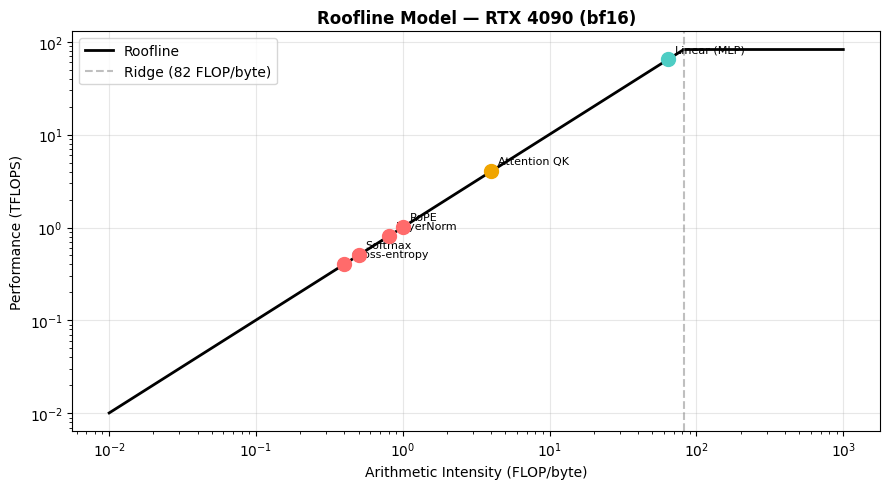


Key insight: softmax, layernorm, RoPE are ALL memory-bound.
Fusing them = fewer HBM round-trips = the core of Unsloth's speedup.


In [3]:
import numpy as np
import matplotlib.pyplot as plt

# RTX 4090 specs
peak_bw_gb_s = 1008        # HBM bandwidth
peak_flops_tflops = 82.6   # bf16 tensor core TFLOPS
ridge_point = peak_flops_tflops * 1e12 / (peak_bw_gb_s * 1e9)  # FLOP/byte

arithmetic_intensities = np.logspace(-2, 3, 300)  # FLOP/byte
roofline = np.minimum(
    arithmetic_intensities * peak_bw_gb_s * 1e9,  # memory-bound ceiling (FLOP/s)
    peak_flops_tflops * 1e12,                      # compute-bound ceiling (FLOP/s)
) / 1e12  # convert to TFLOPS

# Typical ops and their arithmetic intensities
ops = {
    "Softmax":      (0.5,  "memory-bound"),
    "LayerNorm":    (0.8,  "memory-bound"),
    "RoPE":         (1.0,  "memory-bound"),
    "Cross-entropy":(0.4,  "memory-bound"),
    "Attention QK": (4.0,  "memory-bound at short seq"),
    "Linear (MLP)": (64.0, "compute-bound"),
}

fig, ax = plt.subplots(figsize=(9, 5))
ax.loglog(arithmetic_intensities, roofline, 'k-', linewidth=2, label="Roofline")
ax.axvline(ridge_point, color='gray', linestyle='--', alpha=0.5, label=f"Ridge ({ridge_point:.0f} FLOP/byte)")

colors = {"memory-bound": "#FF6B6B", "memory-bound at short seq": "#F0A500", "compute-bound": "#4ECDC4"}
for name, (ai, bound) in ops.items():
    perf = min(ai * peak_bw_gb_s * 1e9, peak_flops_tflops * 1e12) / 1e12
    ax.scatter(ai, perf, s=100, color=colors[bound], zorder=5)
    ax.annotate(name, (ai, perf), textcoords="offset points", xytext=(5, 5), fontsize=8)

ax.set_xlabel("Arithmetic Intensity (FLOP/byte)")
ax.set_ylabel("Performance (TFLOPS)")
ax.set_title("Roofline Model — RTX 4090 (bf16)", fontweight="bold")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("../results/nb02-roofline.png", dpi=150)
plt.show()
print(f"\nKey insight: softmax, layernorm, RoPE are ALL memory-bound.")
print(f"Fusing them = fewer HBM round-trips = the core of Unsloth's speedup.")

## 3. Why naive softmax wastes bandwidth

Naive softmax on a matrix of shape `[batch, N]` requires **multiple passes** over HBM:
1. Read x → compute max(x, dim=-1)
2. Read x → compute sum(exp(x - max))
3. Read x → write x / sum

That's 3 reads + 1 write = **4 × bytes** of HBM traffic.
A fused kernel does it in **1 pass**: 1 read + 1 write — 2× less data movement.
Online softmax (Milakov & Gimelshein, 2018) achieves exactly this. Flash attention exploits it. We build it in NB04.

In [4]:
import torch, time

# Use 2D tensor: batch × sequence — matches real transformer use (e.g. attention scores)
# Shape: 1024 rows × 32768 cols ≈ 32M elements total
ROWS, COLS = 1024, 32768
x = torch.randn(ROWS, COLS, device="cuda", dtype=torch.bfloat16)
N = ROWS * COLS

def naive_softmax(x):
    # Forces separate kernel launches = multiple HBM passes
    x_max = x.max(dim=-1, keepdim=True).values
    x_exp = (x - x_max).exp()
    return x_exp / x_exp.sum(dim=-1, keepdim=True)

def fused_softmax(x):
    return torch.nn.functional.softmax(x, dim=-1)

def bench(fn, n=50):
    for _ in range(5): fn()
    torch.cuda.synchronize()
    t0 = time.perf_counter()
    for _ in range(n): fn()
    torch.cuda.synchronize()
    return (time.perf_counter() - t0) / n * 1000

t_naive = bench(lambda: naive_softmax(x))
t_fused = bench(lambda: fused_softmax(x))

bytes_naive = 4 * N * 2  # 4 passes × 2 bytes (bf16)
bytes_fused = 2 * N * 2  # 2 passes (read + write)

print(f"Naive softmax:  {t_naive:.3f} ms  ({bytes_naive/t_naive*1e-9/1e-3:.0f} GB/s effective)")
print(f"Fused softmax:  {t_fused:.3f} ms  ({bytes_fused/t_fused*1e-9/1e-3:.0f} GB/s effective)")
print(f"Speedup: {t_naive/t_fused:.2f}×")
print(f"\nNote: input shape {x.shape} — realistic transformer use case (batch × seq/vocab)")

Naive softmax:  0.533 ms  (504 GB/s effective)
Fused softmax:  0.148 ms  (904 GB/s effective)
Speedup: 3.59×

Note: input shape torch.Size([1024, 32768]) — realistic transformer use case (batch × seq/vocab)


## 4. Vocabulary

Terms used throughout this series:
- **HBM** — High Bandwidth Memory, the large DRAM on the GPU (~24 GB on 4090)
- **SRAM** — On-chip shared memory per SM (~100 KB per SM), 100× faster than HBM
- **Occupancy** — fraction of max warps active on an SM; higher = better latency hiding
- **Warp** — 32 threads that execute together (SIMT unit)
- **Memory-bound** — op is waiting for HBM; more compute won't help
- **Compute-bound** — op is waiting for tensor cores; more memory won't help
- **Kernel fusion** — combine multiple memory-bound ops into one kernel launch, reducing HBM round-trips

**Next:** NB03 introduces Triton so we can write fused kernels ourselves.